<a href="https://colab.research.google.com/github/mehdi-belhamiti/Hierarchical-Risk-Parity-Python/blob/main/Hierarchical_Risk_Parity_Python_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
import scipy.spatial.distance as ssd

In [15]:
# Sélection de 10 actifs pour le portfolio
tickers = ['SPY', 'TLT', 'GLD', 'VIXY', 'USO', 'VNQ', 'EEM', 'BTC-USD', 'UUP', 'FXY']

# Récupération des données des 5 dernieres années
data = yf.download(tickers, period="5y")['Close']

# calcul des rendements journaliers et en enlevant les valeurs manquantes
returns = data.pct_change(fill_method=None).dropna()

corr_matrix = returns.corr()

#Matrice de distance pour le modèle HRP
#Formule : D = sqrt(0.5 * (1 - Corrélation))
distance_matrix = np.sqrt(np.clip(0.5 * (1 - corr_matrix), 0, 1))

print("\ndim rendements :", returns.shape)

/tmp/ipykernel_1666/3924924123.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period="5y")['Close']
[*********************100%***********************]  10 of 10 completed



dim rendements : (977, 10)


[0.56297336 0.68998568 0.65656678 0.52594612 0.71264912 0.68961225
 0.77731493 0.82815871 0.59876474 0.64985783 0.55639553 0.39832355
 0.6698243  0.69951396 0.85775204 0.88190368 0.53847907 0.56331744
 0.70797613 0.57329839 0.72242721 0.90905518 0.67131383 0.64784135
 0.64484161 0.61703744 0.67624449 0.85271879 0.73146863 0.64096814
 0.67558364 0.67604394 0.80088719 0.94150223 0.4093145  0.7611423
 0.79594478 0.71485283 0.59759651 0.7105555  0.72304247 0.69419155
 0.64646719 0.81572631 0.87123086]


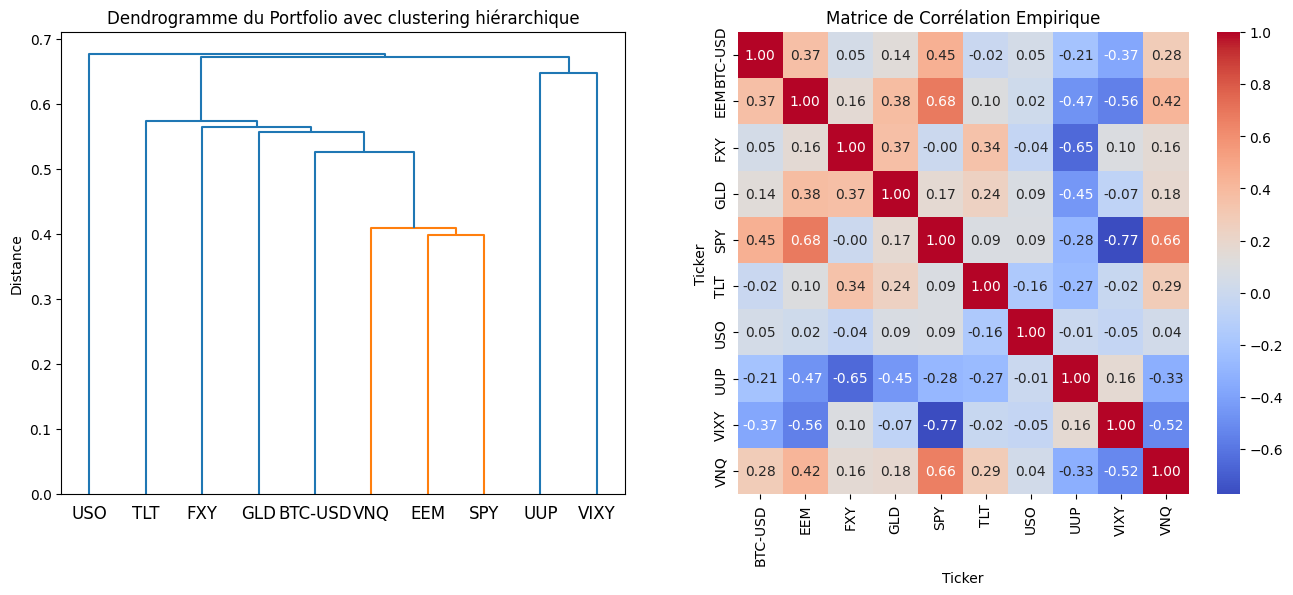

In [21]:
condensed_dist = ssd.squareform(distance_matrix)
print (condensed_dist)

# Clustering hiérarchique
Z = linkage(condensed_dist, method='single')

# visualisation dendrogramme et heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dendrogram(Z, labels=distance_matrix.columns, ax=axes[0])
axes[0].set_title("Dendrogramme du Portfolio avec clustering hiérarchique")
axes[0].set_ylabel("Distance")

sns.heatmap(corr_matrix, annot=True,fmt='.2f',cmap='coolwarm',
            xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns,
            ax=axes[1])
axes[1].set_title("Matrice de Corrélation Empirique")
plt.show()

In [45]:
# matrice de cov
cov_matrix = returns.cov()

# On recupere l'ordre avec le dendrogramme
sort_ix = dendrogram(Z,no_plot = True)['leaves']
sorted_tickers = returns.columns[sort_ix]

print("Ordre des actifs :", sorted_tickers.tolist())

# Fonction pr calculer la variance d'un cluster
def get_cluster_var(cov, c_items):
    # on isole la sous matrice
    cov_ = cov.iloc[c_items, c_items]
    # calcul de l'inverse de la variance
    ivp = 1.0 / np.diag(cov_)
    ivp /= ivp.sum()
    w_ = ivp.reshape(-1, 1)
    # Variance totale w^T * Cov * w
    return np.dot(np.dot(w_.T, cov_), w_)[0, 0]

def get_rec_bipart(cov, sort_ix):
    # on met 100% du poids au debut
    w = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix]

    while len(c_items) > 0:
        #On coupe chaque cluster en 2
        c_items = [i[j:k] for i in c_items for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]

        for i in range(0, len(c_items), 2):
            c_1 = c_items[i]
            c_2 = c_items[i + 1]

            # Risque de chaque moitie
            var_1 = get_cluster_var(cov, c_1)
            var_2 = get_cluster_var(cov, c_2)

            # Facteur alpha pourr donner + de poids au moins risqué
            alpha = 1 - var_1 / (var_1 + var_2)

            # maj des poids
            w[c_1] *= alpha
            w[c_2] *= (1 - alpha)

    return w

Ordre des actifs : ['USO', 'TLT', 'FXY', 'GLD', 'BTC-USD', 'VNQ', 'EEM', 'SPY', 'UUP', 'VIXY']


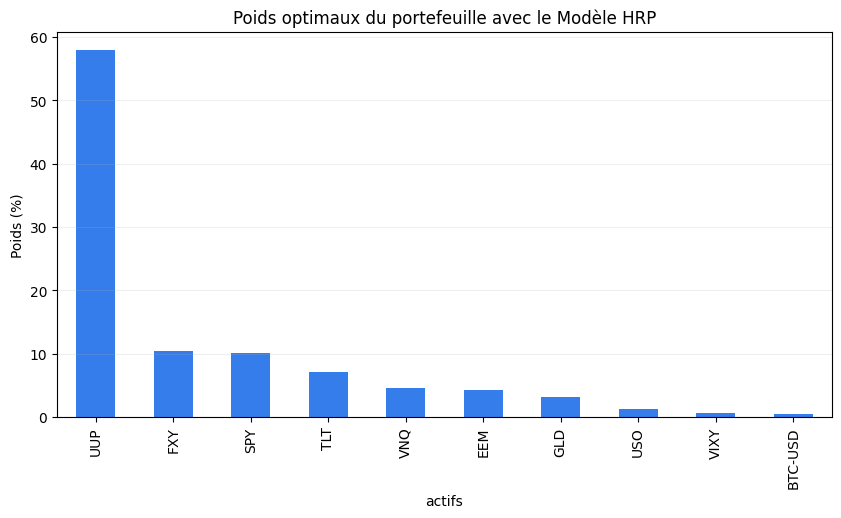


allocation finale :
UUP      : 57.87 %
FXY      : 10.48 %
SPY      : 10.12 %
TLT      : 7.11 %
VNQ      : 4.52 %
EEM      : 4.23 %
GLD      : 3.17 %
USO      : 1.34 %
VIXY     : 0.69 %
BTC-USD  : 0.48 %


In [57]:
# Calcul final des poids
hrp_weights = get_rec_bipart(cov_matrix, sort_ix)

# on remet les vrais tickers pour sy retrouver
hrp_weights.index = corr_matrix.columns[hrp_weights.index]
hrp_weights = hrp_weights * 100
hrp_weights = hrp_weights.sort_values(ascending=False)

#Plot
plt.figure(figsize=(10, 5))
hrp_weights.plot(kind='bar', color='#347deb')
plt.title("Poids optimaux du portefeuille avec le Modèle HRP")
plt.ylabel("Poids (%)")
plt.xlabel("actifs")
plt.grid(axis='y', alpha=0.2)
plt.show()

print("\nallocation finale :")
for ticker, weight in hrp_weights.items():
    print(f"{ticker:8} : {weight:.2f} %")